# ZQE with Fixed $\tilde{Z}$ Pool

**Identical to `exp_A_sparse_loadings.ipynb` (Poisson MAP encoder arm), one change only:**

| | exp_A | this notebook |
|---|---|---|
| $\tilde{z}_0$ | `g.sample_z(batch)` — fresh each step | `Z_sim[random_idx]` — **fixed pool**, drawn once |
| $\tilde{y}$ | `g.sample(z=zq0)` — same | same |
| encoder real | `enc.sample(batch)` — LBFGS | same |
| encoder sim | `enc.sample(yq)` — LBFGS | same |
| loss | `-(m1-m2)`, `zq_log = y·η` cross-term only | same |
| optimiser | SGD + flat+RM + EMA | same |

**`zq_log` = `T(y) * eta` = `y * η`** — cross-term only, no `exp(η)`. The `exp(η)` terms cancel in expectation and carry no gradient information for identifiability.

**Why fix $\tilde{Z}$**: variance of the centering term is $O(1/M)$ instead of $O(1/B)$ — effectively zero with $M = 10N$.


In [70]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math, time
from scipy.linalg import orthogonal_procrustes
from torch.optim.swa_utils import AveragedModel

# ── Config ────────────────────────────────────────────────────────────────────
N          = 2000
P          = 10
Q          = 2
M_MULT     = 10       # M = M_MULT * N  — fixed Z_sim pool size
M          = M_MULT * N
RIDGE      = 1.0      # L2 on Z in encoder only (not in outer objective)
EPOCHS     = 1000     # same role as 'epochs' in exp_A
LR_INIT    = 1.0      # SGD lr_init (same as Poisson MAP arm in exp_A)
FLAT_FRAC  = 0.2      # fraction of epochs at flat LR
RM_ALPHA   = 0.5      # Robbins-Monro decay exponent
RM_A       = 2.0      # Robbins-Monro a parameter
BATCH_SIZE = 1000     # mini-batch size (same as exp_A)
N_MC       = 4        # Monte Carlo reps per batch (same as exp_A)
EMA_DECAY  = 0.95     # EMA decay (same as exp_A)
EMA_START  = 20       # epoch to start EMA (same as exp_A)
DATA_SEED  = 42
DRAW_SEED  = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}  N={N}  P={P}  Q={Q}  M={M}  batch={BATCH_SIZE}  n_mc={N_MC}")


device=cuda  N=2000  P=10  Q=2  M=20000  batch=1000  n_mc=4


In [71]:
def generate_poisson_gllvm(N, P, Q, seed=42, device=device):
    g = torch.Generator()
    g.manual_seed(seed)
    W_true = torch.randn(P, Q, generator=g) * 0.5
    b_true = torch.randn(P,    generator=g) * 0.3
    Z_true = torch.randn(N, Q, generator=g)
    with torch.no_grad():
        lam = (Z_true @ W_true.T + b_true).clamp(-6, 6).exp()
        Y   = torch.poisson(lam)
    return Y.to(device), W_true.to(device), b_true.to(device), Z_true.to(device)


def get_fixed_Z_sim(M, Q, seed=DRAW_SEED, device=device):
    """Draw Z_sim [M, Q] ~ N(0,I) once and freeze forever."""
    g = torch.Generator()
    g.manual_seed(seed)
    return torch.randn(M, Q, generator=g).to(device)


def procrustes_align(W_true, W_est):
    A = W_true.detach().cpu().numpy()
    B = W_est.detach().cpu().numpy()
    R = np.array([[float(np.sign((B*A).sum()))]]) if A.shape[1]==1 \
        else orthogonal_procrustes(B, A)[0]
    return torch.from_numpy((B @ R).astype(np.float32)).to(W_true.device), R


Y, W_true, b_true, Z_true = generate_poisson_gllvm(N, P, Q, seed=DATA_SEED)
Z_sim = get_fixed_Z_sim(M, Q, seed=DRAW_SEED)
print(f"Y {Y.shape}  mean={Y.mean():.2f}  Z_sim {Z_sim.shape}")


Y torch.Size([2000, 10])  mean=1.37  Z_sim torch.Size([20000, 2])


## Poisson MAP Encoder (L-BFGS)

Solves per-observation:
$$\hat{z}_i = \arg\max_z \left\{ \sum_j [y_{ij}\,(w_j^\top z + b_j) - e^{w_j^\top z + b_j}] - \tfrac{1}{2}\|z\|^2 \right\}$$

via L-BFGS with warm-start from Gaussian/log1p closed form.


In [72]:
def impute_Z_lbfgs(W, b, Y, ridge=RIDGE, max_iter=50, history_size=10):
    """
    Poisson MAP encoder via L-BFGS.
    Warm-start: closed-form Gaussian/log1p solution.
    Returns Z_hat [N, Q], fully detached.
    """
    with torch.no_grad():
        W_d = W.detach()
        b_d = b.detach()
        L   = torch.log1p(Y.float())               # [N, P]
        # Gaussian/log1p closed form: z = (W^T W + λI)^{-1} W^T (l - b)
        A   = torch.linalg.solve(
                W_d.T @ W_d + ridge * torch.eye(Q, device=device),
                W_d.T)                             # [Q, P]
        z_init = (L - b_d) @ A.T                  # [N, Q]

    z = torch.nn.Parameter(z_init.detach().clone())

    opt = torch.optim.LBFGS([z], max_iter=max_iter,
                             history_size=history_size,
                             line_search_fn="strong_wolfe")
    W_d2 = W.detach()
    b_d2 = b.detach()
    Y_f  = Y.float()

    def closure():
        opt.zero_grad()
        eta = (z @ W_d2.T + b_d2).clamp(-60., 60.)   # [N, P]
        neg_map = (eta.exp() - Y_f * eta).sum() + 0.5 * ridge * (z ** 2).sum()
        neg_map.backward()
        return neg_map

    opt.step(closure)
    return z.detach()


# ── Quick sanity at true params ───────────────────────────────────────────────
W_test = W_true.clone().requires_grad_(False)
b_test = b_true.clone().requires_grad_(False)
Z_hat_test = impute_Z_lbfgs(W_test, b_test, Y)
r_Z0 = np.corrcoef(Z_true.cpu().numpy().T, Z_hat_test.cpu().numpy().T)
print("Encoder sanity (true W,b) — Z_true vs Z_hat corr per dim:")
for q in range(Q):
    print(f"  Q{q}: r={r_Z0[q, Q+q]:.4f}")


Encoder sanity (true W,b) — Z_true vs Z_hat corr per dim:
  Q0: r=0.7893
  Q1: r=0.8842


In [76]:
def _flat_rm_scheduler(opt, epochs, flat_frac=0.2, rm_alpha=0.5, rm_a=2.0):
    flat_ep = int(flat_frac * epochs)
    def lr_lambda(ep):
        if ep < flat_ep:
            return 1.0
        t = ep - flat_ep + 1
        return 1.0 / (rm_a + t) ** rm_alpha * rm_a ** rm_alpha
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


def fit_zqe_fixed_Z(Y, Z_sim, Q,
                    lr_init=LR_INIT, epochs=EPOCHS,
                    flat_frac=FLAT_FRAC, rm_alpha=RM_ALPHA, rm_a=RM_A,
                    batch_size=BATCH_SIZE, n_mc=N_MC,
                    ema_decay=EMA_DECAY, ema_start=EMA_START,
                    ridge=RIDGE, W_true=None):
    """
    ZQE with fixed Z_sim pool — exact copy of exp_A's run_zqe with PoissonMAPEncoder.

    Uses zq_log = T(y) * eta = y * eta  (cross-term ONLY, no exp(eta)).
    This is the identifiable ZQE objective: the exp(eta) terms cancel at the
    population level regardless of (W,b), so they carry no information.

    ONLY difference from exp_A: zq0 drawn from fixed Z_sim pool.
    """
    N_obs, P = Y.shape
    M_pool   = Z_sim.shape[0]

    # ── Warm start: SVD of log1p(Y) ───────────────────────────────────────────
    log1pY   = torch.log1p(Y.float())
    log1pY_c = log1pY - log1pY.mean(0)
    _, S_svd, Vh_svd = torch.linalg.svd(log1pY_c, full_matrices=False)
    W = torch.nn.Parameter(
        (Vh_svd[:Q].T * (S_svd[:Q] / N_obs**0.5)).contiguous().to(device))
    b = torch.nn.Parameter(log1pY.mean(0).contiguous().to(device))

    opt       = torch.optim.SGD([W, b], lr=lr_init)
    scheduler = _flat_rm_scheduler(opt, epochs, flat_frac, rm_alpha, rm_a)

    W_ema = W.data.clone()
    b_ema = b.data.clone()

    h_err, h_err_ema, h_loss = [], [], []
    t0 = time.time()

    if W_true is not None:
        Wt_np = W_true.cpu().numpy()
        R0, _ = orthogonal_procrustes(W.detach().cpu().numpy(), Wt_np)
        proc0 = float(np.linalg.norm(Wt_np - W.detach().cpu().numpy() @ R0) / np.linalg.norm(Wt_np))
        print(f"start  Proc={proc0:.4f}  lr_init={lr_init:.1e}  flat({int(flat_frac*100)}%)+RM α={rm_alpha} a={rm_a}")

    for ep in range(epochs):
        ep_loss, n_b = 0.0, 0
        perm = torch.randperm(N_obs, device=device)

        for i in range(0, N_obs, batch_size):
            batch = Y[perm[i : i + batch_size]].float()   # [B, P]
            B = len(batch)

            m1_vals, m2_vals = [], []
            for _ in range(n_mc):
                with torch.no_grad():
                    # draw zq0 from FIXED Z_sim pool (only change vs exp_A)
                    sim_idx = torch.randperm(M_pool, device=device)[:B]
                    zq0 = Z_sim[sim_idx]                           # [B, Q]

                    # generate yq — same as g.sample(z=zq0)
                    eta_q = (zq0 @ W.detach().T + b.detach()).clamp(-20., 20.)
                    yq    = torch.poisson(eta_q.exp()).float()     # [B, P]

                    # encode real batch — same as enc.sample(batch)
                    z  = impute_Z_lbfgs(W, b, batch, ridge=ridge)  # [B, Q]

                    # encode sim batch — same as enc.sample(yq)
                    zq = impute_Z_lbfgs(W, b, yq,   ridge=ridge)  # [B, Q]

                # zq_log = T(y) * eta = y * eta  (cross-term only, no exp)
                # same as g.zq_log(y, z=z).sum(-1) in exp_A
                m1v = (batch * (z  @ W.T + b)).sum(1).mean()
                m2v = (yq    * (zq @ W.T + b)).sum(1).mean()

                m1_vals.append(m1v)
                m2_vals.append(m2v)

            m1   = torch.stack(m1_vals).mean()
            m2   = torch.stack(m2_vals).mean()
            loss = -(m1 - m2)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_([W, b], 5.0)
            if not torch.isnan(loss):
                opt.step()

            ep_loss += loss.item(); n_b += 1

        mean_loss = ep_loss / n_b
        scheduler.step()

        if ep >= ema_start:
            W_ema = ema_decay * W_ema + (1 - ema_decay) * W.data
            b_ema = ema_decay * b_ema + (1 - ema_decay) * b.data

        h_loss.append(mean_loss)

        if W_true is not None:
            W_np  = W.detach().cpu().numpy()
            R, _  = orthogonal_procrustes(W_np, Wt_np)
            proc  = float(np.linalg.norm(Wt_np - W_np @ R) / np.linalg.norm(Wt_np))
            W_ema_np = W_ema.cpu().numpy()
            Re, _ = orthogonal_procrustes(W_ema_np, Wt_np)
            proc_e = float(np.linalg.norm(Wt_np - W_ema_np @ Re) / np.linalg.norm(Wt_np))
            h_err.append(proc)
            h_err_ema.append(proc_e)
            if (ep + 1) % 100 == 0:
                print(f"  ep {ep+1:4d}/{epochs}  loss={mean_loss:+.4f}"
                      f"  Proc={proc:.4f}  Proc(EMA)={proc_e:.4f}"
                      f"  lr={opt.param_groups[0]['lr']:.2e}"
                      f"  {time.time()-t0:.0f}s")

    print(f"final  raw={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}" if h_err else "done")
    return W.detach(), b.detach(), W_ema, b_ema, h_loss, h_err, h_err_ema


W_est, b_est, W_ema, b_ema, h_loss, h_err, h_err_ema = fit_zqe_fixed_Z(
    Y, Z_sim, Q, W_true=W_true)


start  Proc=0.4467  lr_init=1.0e+00  flat(20%)+RM α=0.5 a=2.0
  ep  100/1000  loss=+33.5133  Proc=1.2347  Proc(EMA)=0.8267  lr=1.00e+00  298s
  ep  100/1000  loss=+33.5133  Proc=1.2347  Proc(EMA)=0.8267  lr=1.00e+00  298s
  ep  200/1000  loss=+41.5068  Proc=2.5945  Proc(EMA)=0.7130  lr=8.16e-01  616s
  ep  200/1000  loss=+41.5068  Proc=2.5945  Proc(EMA)=0.7130  lr=8.16e-01  616s
  ep  300/1000  loss=+0.0788  Proc=0.0681  Proc(EMA)=0.0654  lr=1.39e-01  815s
  ep  300/1000  loss=+0.0788  Proc=0.0681  Proc(EMA)=0.0654  lr=1.39e-01  815s
  ep  400/1000  loss=+0.5770  Proc=0.0634  Proc(EMA)=0.0592  lr=9.93e-02  981s
  ep  400/1000  loss=+0.5770  Proc=0.0634  Proc(EMA)=0.0592  lr=9.93e-02  981s
  ep  500/1000  loss=+0.6353  Proc=0.0683  Proc(EMA)=0.0609  lr=8.12e-02  1136s
  ep  500/1000  loss=+0.6353  Proc=0.0683  Proc(EMA)=0.0609  lr=8.12e-02  1136s
  ep  600/1000  loss=-0.1548  Proc=0.0624  Proc(EMA)=0.0598  lr=7.04e-02  1298s
  ep  600/1000  loss=-0.1548  Proc=0.0624  Proc(EMA)=0.0598  l

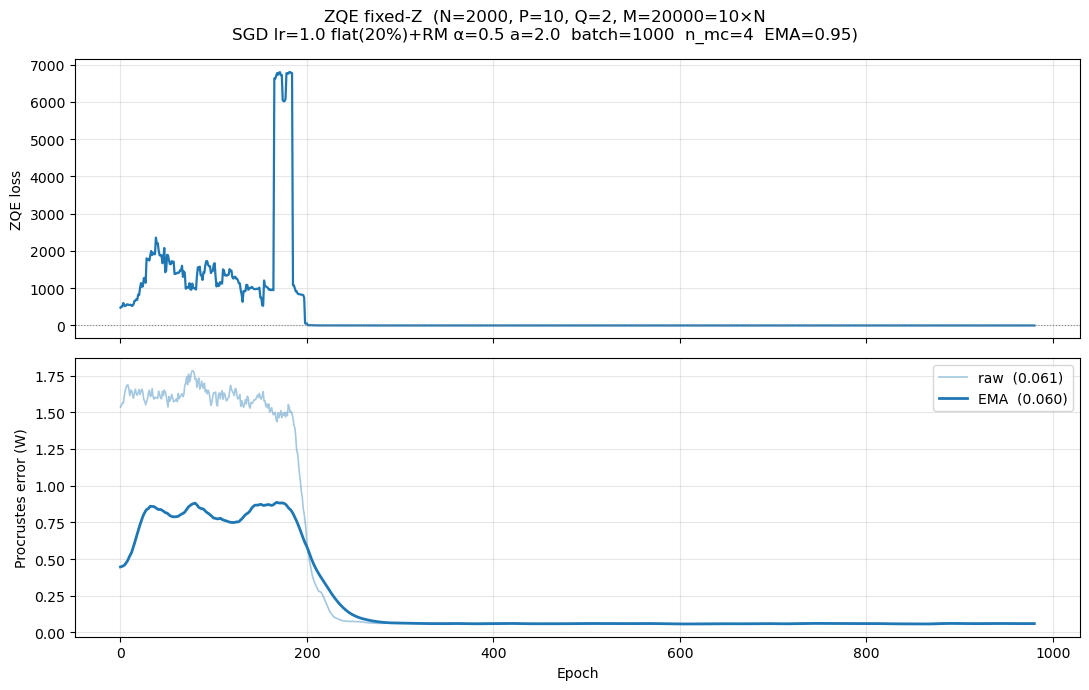

In [77]:
# ── Diagnostic plots — same layout as exp_A ──────────────────────────────────
def sm(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

xs = np.arange(len(sm(h_loss)))

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle(f"ZQE fixed-Z  (N={N}, P={P}, Q={Q}, M={M}={M_MULT}×N\n"
             f"SGD lr={LR_INIT} flat({int(FLAT_FRAC*100)}%)+RM α={RM_ALPHA} a={RM_A}  "
             f"batch={BATCH_SIZE}  n_mc={N_MC}  EMA={EMA_DECAY})")

ax0.plot(xs, sm(h_loss), lw=1.6)
ax0.axhline(0, color='gray', ls=':', lw=0.8)
ax0.set_ylabel("ZQE loss"); ax0.grid(True, alpha=0.3)

if h_err:
    ax1.plot(xs, sm(h_err),     lw=1.2, alpha=0.4, color='tab:blue',   label=f"raw  ({h_err[-1]:.3f})")
    ax1.plot(xs, sm(h_err_ema), lw=2.0,             color='tab:blue',   label=f"EMA  ({h_err_ema[-1]:.3f})")
ax1.set_ylabel("Procrustes error (W)"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Evaluation


── raw W ──
[raw]  W — r=0.9987  MAE=0.0235   Z — r=0.8374  MAE=0.4223
── EMA W ──
[EMA]  W — r=0.9987  MAE=0.0222   Z — r=0.8373  MAE=0.4220
[EMA]  W — r=0.9987  MAE=0.0222   Z — r=0.8373  MAE=0.4220


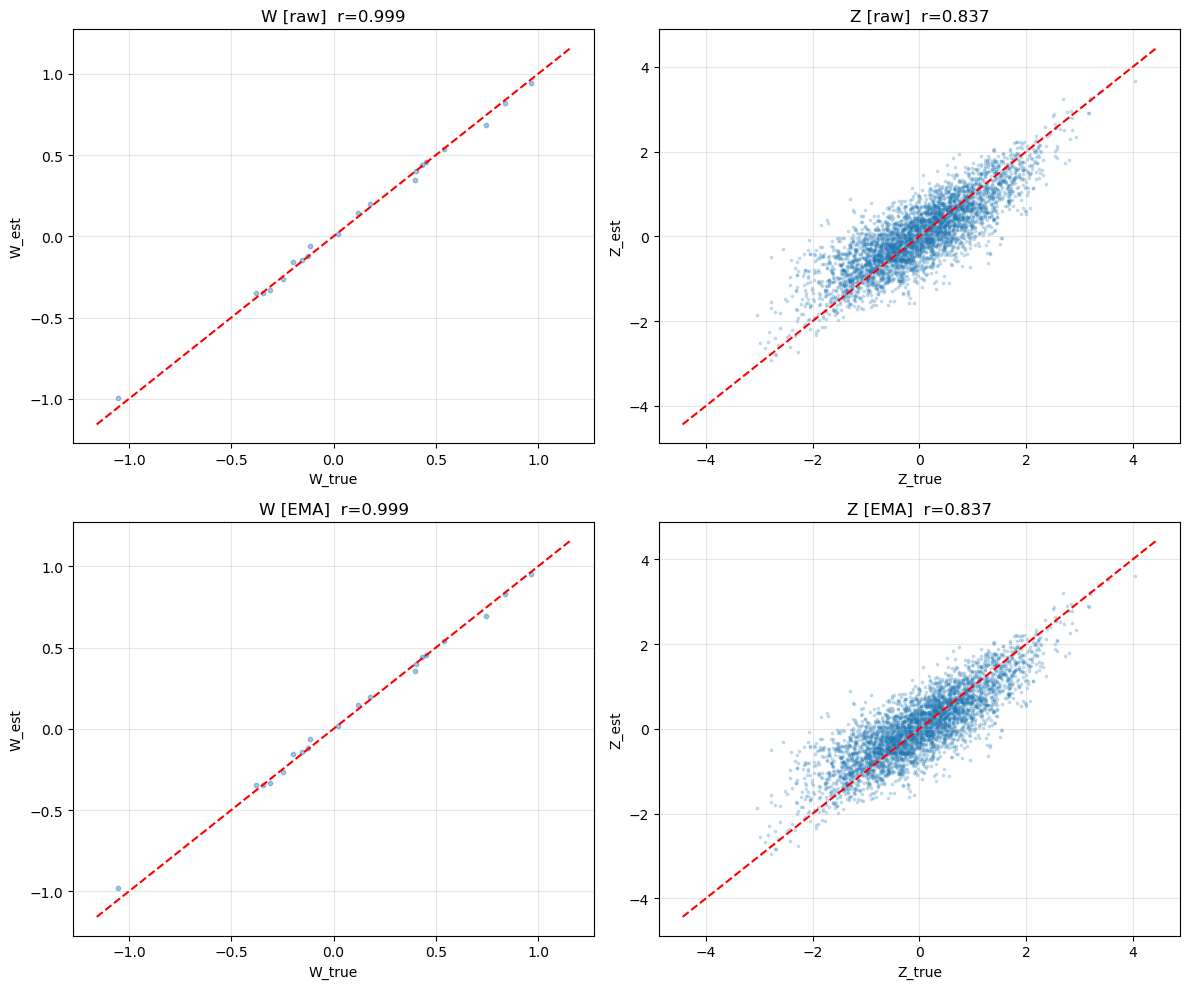

In [78]:
from scipy.linalg import orthogonal_procrustes

def eval_W_Z(W_est, b_est, label=""):
    W_np  = W_est.cpu().numpy()
    Wt_np = W_true.cpu().numpy()
    R, _  = orthogonal_procrustes(W_np, Wt_np)
    W_al  = torch.from_numpy((W_np @ R).astype(np.float32)).to(device)
    r_W   = torch.corrcoef(torch.stack([W_true.flatten(), W_al.flatten()]))[0,1].item()
    mae_W = (W_al - W_true).abs().mean().item()

    Z_hat_f = impute_Z_lbfgs(W_est, b_est, Y)
    Z_al    = torch.from_numpy((Z_hat_f.cpu().numpy() @ R).astype(np.float32)).to(device)
    r_Z     = torch.corrcoef(torch.stack([Z_true.flatten(), Z_al.flatten()]))[0,1].item()
    mae_Z   = (Z_al - Z_true).abs().mean().item()

    tag = f"[{label}]  " if label else ""
    print(f"{tag}W — r={r_W:.4f}  MAE={mae_W:.4f}   Z — r={r_Z:.4f}  MAE={mae_Z:.4f}")
    return W_al, Z_al, R

print("── raw W ──")
W_al_raw, Z_al_raw, R_raw = eval_W_Z(W_est, b_est, "raw")
print("── EMA W ──")
W_al_ema, Z_al_ema, R_ema = eval_W_Z(W_ema.to(device), b_ema.to(device), "EMA")

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (W_al, Z_al, lbl) in enumerate([(W_al_raw, Z_al_raw, "raw"), (W_al_ema, Z_al_ema, "EMA")]):
    ax = axes[row, 0]
    wt = W_true.cpu().numpy().flatten()
    we = W_al.cpu().numpy().flatten()
    r_W = torch.corrcoef(torch.stack([W_true.flatten(), W_al.flatten()]))[0,1].item()
    ax.scatter(wt, we, s=10, alpha=0.4)
    lim = max(abs(wt).max(), abs(we).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5)
    ax.set_xlabel("W_true"); ax.set_ylabel("W_est")
    ax.set_title(f"W [{lbl}]  r={r_W:.3f}"); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    zt = Z_true.cpu().numpy().flatten()
    ze = Z_al.cpu().numpy().flatten()
    r_Z = torch.corrcoef(torch.stack([Z_true.flatten(), Z_al.flatten()]))[0,1].item()
    ax.scatter(zt, ze, s=3, alpha=0.2)
    lim = max(abs(zt).max(), abs(ze).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5)
    ax.set_xlabel("Z_true"); ax.set_ylabel("Z_est")
    ax.set_title(f"Z [{lbl}]  r={r_Z:.3f}"); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
